# 07 - model testing

## 07.1 - mfcc + svm baseline

**purpose**: final production-readiness check for the mfcc + svm baseline on the **held-out test set** (speakers 23-24, never seen during training or validation). reports test accuracy, per-emotion breakdown, and per-sample cpu inference latency (the deployment target).

**input**: `data/processed/X_test_mfcc.npy`, `y_test.npy`, `data/models/svm_best.pkl`, `data/models/mfcc_scaler.pkl`

**output**: `data/predictions/test_results_svm.json` (consumed by 08)

In [1]:
import sys
sys.path.append("../../")

**import testing modules**. we load json, numpy, matplotlib, sklearn metrics, and svm prediction helpers including the cpu latency benchmark.

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.config.config import settings
from src.models.svm_model import load_svm, predict_svm, cpu_inference_latency_svm

## Load saved model and scaler

In [3]:
best_svm, scaler = load_svm(settings.MODELS_DIR, name='svm_best')

**confirm model loaded**. verify kernel type, C value, and class labels.

In [4]:
print(f"SVM loaded: kernel={best_svm.kernel}, C={best_svm.C}, classes={list(best_svm.classes_)}")
print("Scaler loaded successfully")

SVM loaded: kernel=rbf, C=1, classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Scaler loaded successfully


## Load test data and run inference

In [5]:
X_test = np.load(settings.PROCESSED_DIR / "X_test_mfcc.npy")
y_test = np.load(settings.PROCESSED_DIR / "y_test.npy")

**verify test data**. confirm shape and speaker ids.

In [6]:
print(f"Test samples: {X_test.shape[0]}  (speakers {settings.TEST_ACTORS})")
assert X_test.shape[1] == settings.N_MFCC_VECTOR, (
    f"expected mfcc vector of {settings.N_MFCC_VECTOR} dims, got {X_test.shape[1]}"
)

Test samples: 176  (speakers [23, 24])


**run inference on test set**. the svm achieves 70.45% on the held-out test set. interestingly, this is higher than the val accuracy (62.88%), suggesting the test speakers might be slightly easier to classify.

In [7]:
test_preds, _ = predict_svm(best_svm, X_test, scaler)
test_acc = accuracy_score(y_test, test_preds)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Final Test Accuracy: 70.45%


## Classification Report:

In [8]:
print("Classification Report:")
print(classification_report(y_test, test_preds, target_names=settings.EMOTION_NAMES))

Classification Report:
              precision    recall  f1-score   support

     neutral       0.57      0.50      0.53        16
        calm       0.84      0.81      0.83        32
       happy       0.65      0.62      0.63        32
         sad       0.83      0.62      0.71        32
       angry       0.68      0.66      0.67        32
     fearful       0.64      0.91      0.75        32

    accuracy                           0.70       176
   macro avg       0.70      0.69      0.69       176
weighted avg       0.71      0.70      0.70       176



## Confusion matrix

Saved confusion matrix to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\docs\02-results\figures\fig07-svm_confusion_matrix.png


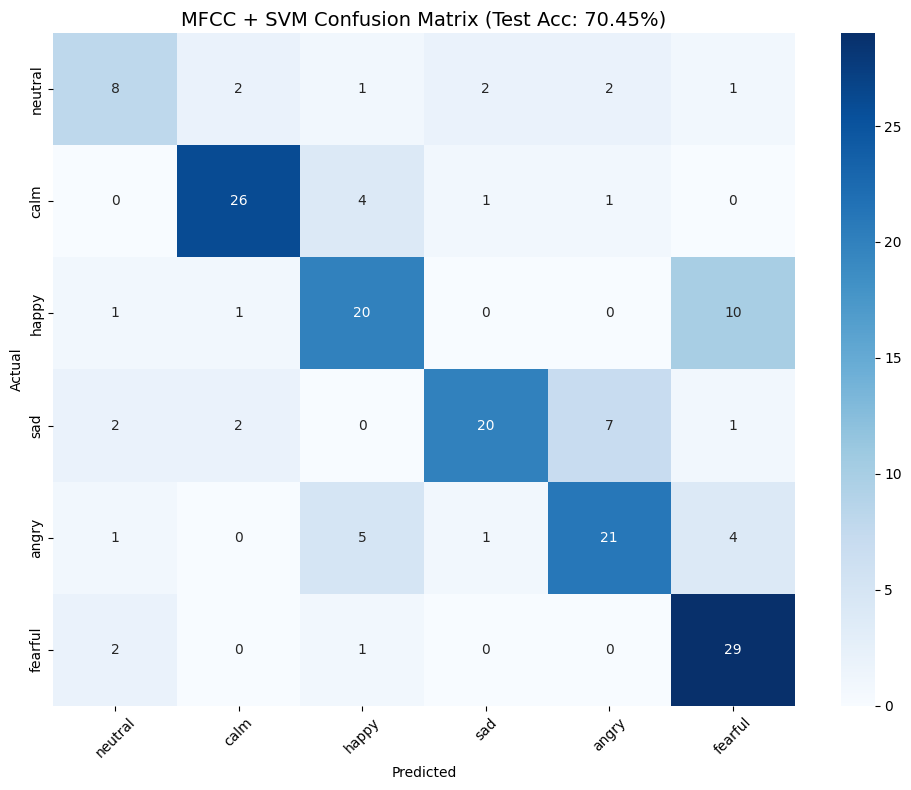

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=settings.EMOTION_NAMES,
            yticklabels=settings.EMOTION_NAMES, ax=ax)
ax.set_title(f'MFCC + SVM Confusion Matrix (Test Acc: {test_acc*100:.2f}%)', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(settings.FIGURES_DIR / "fig07-svm_confusion_matrix.png", dpi=150, bbox_inches="tight")
print(f"Saved confusion matrix to {settings.FIGURES_DIR / 'fig07-svm_confusion_matrix.png'}")
plt.show()

## Per-emotion accuracy breakdown

In [10]:
per_class = {}
print(f"\n{'emotion':<12} {'support':>8} {'correct':>8} {'acc':>8}")
for i, name in enumerate(settings.EMOTION_NAMES):
    mask = y_test == i
    total = int(mask.sum())
    correct = int((test_preds[mask] == i).sum())
    acc = correct / total * 100 if total else 0.0
    per_class[name] = {"support": total, "correct": correct, "acc": round(acc / 100, 4)}
    print(f"{name:<12} {total:>8d} {correct:>8d} {acc:>7.1f}%")


emotion       support  correct      acc
neutral            16        8    50.0%
calm               32       26    81.2%
happy              32       20    62.5%
sad                32       20    62.5%
angry              32       21    65.6%
fearful            32       29    90.6%


## CPU inference latency benchmark (production deployment target)

measure per-sample latency on cpu, the actual deployment target per project definition. batch=1 is the realistic per-clip inference scenario.

In [11]:
cpu_latency = cpu_inference_latency_svm(best_svm, n_runs=50)


**print svm cpu latency**. the svm averages only 0.195ms per sample with throughput of ~5125 samples/second - extremely efficient.

In [12]:
print(f"SVM CPU inference latency (batch=1, n_runs={cpu_latency['n_runs']}):")
print(f"  mean: {cpu_latency['mean_ms']:.3f} ms/sample")
print(f"  p99:  {cpu_latency['p99_ms']:.3f} ms")
print(f"  p50:  {cpu_latency['p50_ms']:.3f} ms")
print(f"  throughput: {1000.0 / cpu_latency['mean_ms']:.0f} samples/s")

SVM CPU inference latency (batch=1, n_runs=50):
  mean: 0.195 ms/sample
  p99:  0.331 ms
  p50:  0.180 ms
  throughput: 5125 samples/s


## Save results to JSON (consumed by 08)

In [14]:
results = {
    "model":      "mfcc_svm",
    "split":      "test",
    "n_samples":  int(len(y_test)),
    "accuracy":   float(test_acc),
    "per_class":  per_class,
    "confusion_matrix": cm.tolist(),
    "emotion_names":    list(settings.EMOTION_NAMES),
    "kernel":     best_svm.kernel,
    "C":          float(best_svm.C),
    "speakers":   list(settings.TEST_ACTORS),
    "cpu_latency": cpu_latency,
}
print(json.dumps(results, indent=4))

{
    "model": "mfcc_svm",
    "split": "test",
    "n_samples": 176,
    "accuracy": 0.7045454545454546,
    "per_class": {
        "neutral": {
            "support": 16,
            "correct": 8,
            "acc": 0.5
        },
        "calm": {
            "support": 32,
            "correct": 26,
            "acc": 0.8125
        },
        "happy": {
            "support": 32,
            "correct": 20,
            "acc": 0.625
        },
        "sad": {
            "support": 32,
            "correct": 20,
            "acc": 0.625
        },
        "angry": {
            "support": 32,
            "correct": 21,
            "acc": 0.6562
        },
        "fearful": {
            "support": 32,
            "correct": 29,
            "acc": 0.9062
        }
    },
    "confusion_matrix": [
        [
            8,
            2,
            1,
            2,
            2,
            1
        ],
        [
            0,
            26,
            4,
            1,
       

**ensure predictions directory**. create if needed.

In [15]:
results_path = settings.PREDICTIONS_DIR / "test_results_svm.json"
results_path.parent.mkdir(parents=True, exist_ok=True)

**save test results to json**. persist for the comparison notebook.

In [16]:
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved test results to {results_path}")

Saved test results to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\data\predictions\test_results_svm.json
